In [1]:
import os 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import h5py
import numpy as np 

from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.lines import Line2D


In [2]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/experiment/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    broadened_dos_normalized = broadened_dos / broadened_area
    return 3*unit_cell_atoms*broadened_dos_normalized



In [22]:
results_directory={"../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/total":"Total" 
                  ,"../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/core":"Core" 
                  ,"../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/shell":"Shell" 
                  ,"../results/lammps/nanoparticle/4nm/lennard_jones/core_shell/results/mdanse/":"Fixed Core" 
                  }
df_list=list()

min_energy=0.25
max_energy=150

for data_directory,system in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        h5file.close()
        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        df_tmp["Temperature (K)"]=int(filename.split("_")[-2].replace('K',''))
        df_tmp["Weight"]=filename.split("_")[-3].replace('b ','').capitalize()
        label="%s lammps"%(system.replace("_"," ").replace("nanoparticle", "np"))
        df_tmp["Method"]="LAMMPS"
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp,unit_cell_atoms=56)
        for species,unit_cell_atoms in {"Fe":24,"O":32}.items():
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species,unit_cell_atoms)
            df_tmp["Max Normalized %s"%species]=df_tmp[species]/df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["Radius (nm)"]=int(directory_split[4].replace("nm",""))
        df_tmp["Software"]=directory_split[2]
        df_tmp["System"]=system #.split("_")[0].replace("nanoparticle", "np")
        df_list.append(df_tmp)
df_dos_lammps=pd.concat(df_list,ignore_index=True)

df_dos_lammps

../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/total\atom_b_incoherent_200K_dos.h5
../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/total\atom_b_incoherent_300K_dos.h5
../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/core\atom_b_incoherent_200K_dos.h5
../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/core\atom_b_incoherent_300K_dos.h5
../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/shell\atom_b_incoherent_200K_dos.h5
../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/mdanse/shell\atom_b_incoherent_300K_dos.h5
../results/lammps/nanoparticle/4nm/lennard_jones/core_shell/results/mdanse/b_incoherent_200K_dos.h5
../results/lammps/nanoparticle/4nm/lennard_jones/core_shell/results/mdanse/b_incoherent_300K_dos.h5


,dos Fe (nm2/ps),dos O (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Temperature (K),Weight,Method,Energy Transfer (meV),Normalized Count,Fe,Max Normalized Fe,O,Max Normalized O,Max Normalized Count,Radius (nm),Software,System
0,1.562885e-06,-5.060671e-06,1.189573e-06,0.439867,0.0,1.000000e+00,200,Incoherent,LAMMPS,0.289520,0.060117,0.037367,0.011495,-0.056736,-0.027244,0.009013,4,lammps,Total
1,-8.171518e-07,5.885300e-06,-4.393931e-07,0.502705,0.0,1.000000e+00,200,Incoherent,LAMMPS,0.330881,-0.005551,-0.004884,-0.001503,0.016495,0.007921,-0.000832,4,lammps,Total
2,1.505900e-06,-5.124616e-06,1.132196e-06,0.565543,0.0,1.000000e+00,200,Incoherent,LAMMPS,0.372241,0.028609,0.018002,0.005538,-0.028727,-0.013794,0.004289,4,lammps,Total
3,-6.713436e-07,5.995584e-06,-2.955871e-07,0.628381,0.0,1.000000e+00,200,Incoherent,LAMMPS,0.413601,-0.003735,-0.004013,-0.001234,0.016804,0.008069,-0.000560,4,lammps,Total
4,1.485661e-06,-5.153363e-06,1.111478e-06,0.691220,0.0,1.000000e+00,200,Incoherent,LAMMPS,0.454961,0.028085,0.017760,0.005464,-0.028888,-0.013871,0.004211,4,lammps,Total
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28955,5.521752e-09,7.724675e-08,9.564264e-09,227.599737,0.0,3.587767e-17,300,Incoherent,LAMMPS,149.806147,0.000737,0.000192,0.000067,0.001332,0.000825,0.000126,4,lammps,Fixed Core
28956,5.506510e-09,7.698632e-08,9.535203e-09,227.662575,0.0,-5.551670e-19,300,Incoherent,LAMMPS,149.847507,0.000735,0.000191,0.000067,0.001328,0.000822,0.000126,4,lammps,Fixed Core
28957,5.491347e-09,7.672707e-08,9.506283e-09,227.725413,0.0,2.006408e-17,300,Incoherent,LAMMPS,149.888867,0.000732,0.000191,0.000067,0.001323,0.000819,0.000125,4,lammps,Fixed Core
28958,5.476267e-09,7.646915e-08,9.477515e-09,227.788251,0.0,1.413941e-18,300,Incoherent,LAMMPS,149.930227,0.000730,0.000190,0.000067,0.001318,0.000816,0.000125,4,lammps,Fixed Core


In [36]:
df_PPR_bulk=pd.read_csv("../results/lammps/bulk/lennard_jones/results/df_PPR_300K.csv")
df_PPR_total=pd.read_csv("../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/df_PPR_300K.csv")
df_f_surf=pd.read_csv("../results/lammps/nanoparticle/4nm/lennard_jones/spherical/results/df_f_surf_300K.csv")

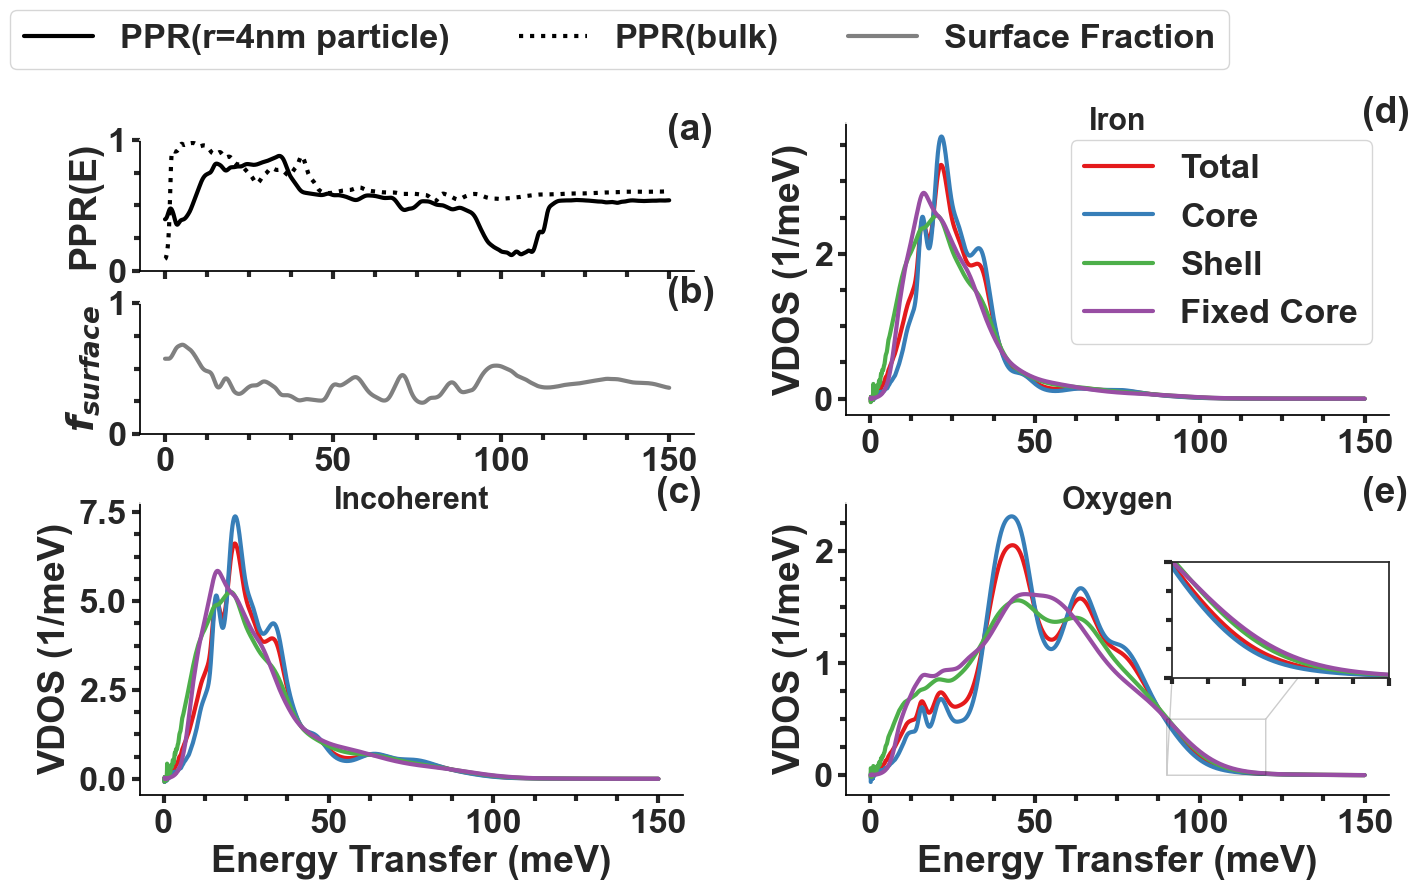

In [68]:
from matplotlib import gridspec

plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")

emin,emax=0,150
weight="Incoherent"
df_tmp=df_dos_lammps.query(" %f < `Energy Transfer (meV)` and `Energy Transfer (meV)` < %f and Weight== '%s' and `Temperature (K)` == 300 "%(emin,emax,weight))

def apply_ax_format(ax,xlabel="",ylabel="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



fig, axs = plt.subplots(ncols=2, nrows=2,figsize=(7*2.1,4*2.1)
                       )

labx=0.95
laby=1
ytitle=0.95

ax=axs[1,0]
ax.text(labx, laby, '(c)',weight='bold' ,transform=ax.transAxes)
ax.set_title(weight,fontsize='22',y=ytitle)

sns.lineplot(data=df_tmp
                    ,y="Normalized Count"
                    ,x='Energy Transfer (meV)'
                    ,hue="System"
                     ,ax=ax
                     ,palette="Set1"
                     ,legend=False
                    ,lw=3
               )


apply_ax_format(ax,xlabel="Energy Transfer (meV)",ylabel="VDOS (1/meV)")

ax=axs[0,0]

pos = ax.get_position()
ax.remove()  # delete the old axis

# Make a GridSpec inside that rectangle
gs = gridspec.GridSpec(2, 1, figure=fig)  # 2 rows, 1 column
gs.update(left=pos.x0-0.025, right=pos.x1, bottom=pos.y0, top=pos.y1, hspace=0.25)

# Now add two new axes
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(labx, laby, '(a)',weight='bold' ,transform=ax1.transAxes)


sns.lineplot(data=df_PPR_total.query("`Energy Transfer (meV)` > 0")
                ,y='PPR'
                ,x='Energy Transfer (meV)'
                ,ax=ax1
                ,legend=False
                ,color="black"
                ,lw=3
                )

sns.lineplot(data=df_PPR_bulk.query("`Energy Transfer (meV)` > 0")
                ,y='PPR'
                ,x='Energy Transfer (meV)'
                ,ax=ax1
                ,legend=False
                ,color="black"
                ,linestyle=":"
                ,lw=3
                )

apply_ax_format(ax1,xlabel="",ylabel="PPR(E)")
ax1.set_xticklabels([])
ax1.set_ylim(0,1)

custom_lines = [Line2D([0], [0], color="black", lw=3),Line2D([0], [0], color="black", lw=3,ls=":") ,Line2D([0], [0], color="grey", lw=3)]
ax1.legend(custom_lines,["PPR(r=4nm particle)","PPR(bulk)","Surface Fraction"])
sns.move_legend(ax1,'center left',bbox_to_anchor=(0.0,1),ncol=3,bbox_transform=fig.transFigure)

ax2 = fig.add_subplot(gs[1, 0])
ax2.text(labx, laby, '(b)',weight='bold' ,transform=ax2.transAxes)

sns.lineplot(data=df_f_surf.query("`Energy Transfer (meV)` > 0")
                ,y='f_surf'
                ,x='Energy Transfer (meV)'
                     ,ax=ax2
                     ,legend=False
                    ,color="grey"
                    ,lw=3
                )


apply_ax_format(ax2,xlabel="",ylabel="$f_{surface}$")
ax2.set_ylim(0,1)



ax=axs[0,1]
ax.text(labx, laby, '(d)',weight='bold' ,transform=ax.transAxes)
ax.set_title("Iron",fontsize='22',y=ytitle)

sns.lineplot(data=df_tmp
                    ,y="Fe"
                    ,x='Energy Transfer (meV)'
                    ,hue="System"
                     ,ax=ax
                     ,palette="Set1"
                     ,legend=True
                    ,lw=3
               )

apply_ax_format(ax,xlabel="",ylabel="VDOS (1/meV)",legend=True)

sns.move_legend(ax,'upper right',bbox_to_anchor=(1,1),ncol=1,title=""
#                   ,bbox_transform=fig.transFigure
                   )

ax=axs[1,1]
ax.text(labx, laby, '(e)',weight='bold' ,transform=ax.transAxes)
ax.set_title("Oxygen",fontsize='22',y=ytitle)

sns.lineplot(data=df_tmp
                    ,y="O"
                    ,x='Energy Transfer (meV)'
                    ,hue="System"
                     ,ax=ax
                     ,palette="Set1"
                     ,legend=False
                    ,lw=3
               )

apply_ax_format(ax,xlabel="Energy Transfer (meV)",ylabel="VDOS (1/meV)")

x1, x2, y1, y2 = 90, 120, 0, 0.5
emax,cmax=df_tmp["Energy Transfer (meV)"].max(),df_tmp["O"].max()
ratio=emax*y2/(x2*cmax)

xw=0.4
axins = ax.inset_axes(
    [0.6, 0.4,0.4, 0.4],
    xlim=(x1, x2)
    , ylim=(y1, y2),xticklabels=[], yticklabels=[]
    #, transform=ax.transData
)
#axins.imshow(Z2, extent=extent, origin="lower")

sns.lineplot(data=df_tmp
                    ,y="O"
                    ,x='Energy Transfer (meV)'
                    ,hue="System"
                     ,palette="Set1"
                    ,legend=False
                     ,ax=axins
                    ,lw=3
               )

#axins.tick_params(direction='out', width=3, length=8, bottom=True, left=True)
#axins.tick_params(which='minor',direction='out', length=8,width=3)
#axins.xaxis.set_ticks([0, 25/4], ["", ""])
#axins.yaxis.set_ticks([0, 5/4], ["", ""])
#axins.grid(False)
#axins.set_xlabel("")
#axins.set_ylabel("")

apply_ax_format(axins,inset=True)
ax.indicate_inset_zoom(axins, edgecolor="black",alpha=0.2)



# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.3, 
                    hspace=0.3
                   )

plt.savefig("../figures/figD1.pdf", pad_inches=0.2,bbox_inches="tight")